# Pretrained atomistic representations in `mlcolvar`

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_atomistic_model.ipynb)


## Introduction

This tutorial shows how to reuse a pretrained atomistic model as a
**frozen molecular representation** for learning a DeepTDA collective variable.

MACE is used as the reference implementation of an external pretrained
atomistic model:

```text
atomic configuration
        ↓
pretrained MACE model
        ↓
MACERepresentation
        ↓
atom-level features
        ↓
pool_representation(...)
        ↓
system-level h(R)
        ↓
TaskHead
        ↓
DeepTDA CV
```

Only the `TaskHead` is optimized during DeepTDA training. Since the
pretrained representation is frozen, its output can be precomputed to avoid
repeatedly evaluating the atomistic backbone.

The same framework can be used with other pretrained atomistic models.
Users can integrate another model by subclassing `GraphRepresentation` and
implementing the model-specific feature extraction in `forward()`.

After training, the optimized head is combined again with the frozen
representation, yielding a complete model that directly accepts atomic
configurations.

**Author:** Kai Zhu


## 1. Load a pretrained MACE representation

`MACERepresentation` is provided as a reference adapter for external
pretrained atomistic models.

The adapter exposes pretrained MACE latent features through the common
`GraphRepresentation` interface while keeping the pretrained model frozen.

The rest of the `mlcolvar` workflow only depends on this common representation
interface, not on MACE itself.


In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch

torch.manual_seed(41)

POOLING = "mean"  # "mean" or "sum"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("./data/alanine_gnn")

BATCH_SIZE = 32
MAX_EPOCHS = 5

print("Pooling:", POOLING)
print("Device:", DEVICE)


Pooling: mean
Device: cuda


### Load the pretrained model

`freeze=True` fixes the pretrained MACE parameters while preserving
differentiability with respect to atomic coordinates.

`SKIP_TUTORIAL` is kept so that the notebook can still be imported or rendered
when the optional MACE dependencies are not installed.


In [2]:
SKIP_TUTORIAL = False
SKIP_REASON = None
representation = None

try:
    torch.set_default_dtype(torch.float32)

    from mace.calculators import mace_mp

    from mlcolvar.representation import MACERepresentation

    calculator = mace_mp(
        model="small",
        device=DEVICE,
        default_dtype="float32",
    )

    representation = MACERepresentation(
        model=calculator.models[0].eval(),
        freeze=True,
    )

except (ImportError, ModuleNotFoundError) as exc:
    SKIP_TUTORIAL = True
    SKIP_REASON = str(exc)

    print(
        "Skipping tutorial: optional MACE dependencies "
        f"are unavailable.\n{SKIP_REASON}"
    )

if not SKIP_TUTORIAL:
    print("Representation:", type(representation).__name__)
    print("Output kind:", representation.output_kind)
    print("Feature dimension:", representation.out_features)
    print(
        "Atomic numbers:",
        representation.atomic_numbers.detach().cpu().tolist(),
    )
    print(
        "Cutoff:",
        float(representation.cutoff.detach().cpu()),
    )


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Materials Project MACE for MACECalculator with /home/kzhu-iit.local/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Representation: MACERepresentation
Output kind: atom
Feature dimension: 256
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Cutoff: 6.0


## 2. Adapting another pretrained atomistic model

MACE is only one example of a pretrained atomistic representation.

Other pretrained models can be integrated into the same workflow by
subclassing `GraphRepresentation`. The adapter is responsible for translating
the `mlcolvar` graph dictionary into the input expected by the pretrained model
and returning its latent representation.

A custom atomistic adapter should provide:

- `out_features`: the dimension of the returned representation;
- `atomic_numbers`: the elements supported by the pretrained model;
- `cutoff`: the interaction cutoff required to build the graph;
- `output_kind`: whether the returned features are atom-level or system-level;
- `forward()`: the model-specific feature extraction.

A minimal adapter can look like this:

```python
from typing import Dict, Optional

import torch
from torch import nn

from mlcolvar.representation import GraphRepresentation


class MyRepresentation(GraphRepresentation):
    def __init__(
        self,
        model: nn.Module,
        *,
        out_features: int,
        atomic_numbers,
        cutoff: float,
        freeze: bool = True,
    ) -> None:
        super().__init__(
            out_features=out_features,
            atomic_numbers=atomic_numbers,
            cutoff=cutoff,
            output_kind="atom",
            freeze=freeze,
        )

        self.model = model
        self._freeze_module(self.model)

    def forward(
        self,
        data: Dict[str, torch.Tensor],
        cell: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Convert the mlcolvar graph dictionary to the format
        # expected by the pretrained model.
        features = self.model(
            positions=data["positions"],
            node_attrs=data["node_attrs"],
            edge_index=data["edge_index"],
        )

        # Atom-level representation:
        # [n_atoms, out_features]
        return features
```

The exact implementation of `forward()` is backend-specific. A model may need
its own atom-type encoding, neighbor-list format, periodic-cell representation,
or feature-selection logic. These details belong in the adapter, while the
downstream `mlcolvar` workflow remains unchanged.

For an atom-level representation, the adapter should return

```text
[n_atoms, n_features]
```

and can then be used exactly like `MACERepresentation`:

```text
MyRepresentation
       ↓
pool_representation(...)
       ↓
RepresentationModel
       ↓
TaskHead
       ↓
CV / committor / other downstream task
```


## 3. Build the graph dataset

The representation provides the cutoff and expected atomic-number ordering.

`align_dataset()` makes the dataset `node_attrs` consistent with the pretrained
model.

MDTraj coordinates are stored in nm, while MACE uses Å, so the coordinates are
converted with `lengths_conversion=10.0`.

From this point on, the workflow only relies on the common representation
interface. The same dataset, pooling, caching, and training utilities can
therefore be reused with a custom `GraphRepresentation`.


In [3]:
if not SKIP_TUTORIAL:
    from mlcolvar.io import create_dataset_from_trajectories

    if not DATA_DIR.exists():
        raise FileNotFoundError(
            f"Dataset directory not found: {DATA_DIR.resolve()}"
        )

    dataset = create_dataset_from_trajectories(
        trajectories=[
            "alad_A.trr",
            "alad_B.trr",
        ],
        topologies="alad.gro",
        folder=str(DATA_DIR),
        cutoff=float(
            representation.cutoff.detach().cpu()
        ),
        system_selection="all",
        show_progress=False,
        load_args=[
            {"start": 0, "stop": 10000, "stride": 5},
            {"start": 0, "stop": 10000, "stride": 5},
        ],
        lengths_conversion=10.0,
    )

    dataset = representation.align_dataset(
        dataset
    )

    print(dataset)
    print(
        "Atomic numbers:",
        dataset.metadata["atomic_numbers"],
    )


/home/kzhu-iit.local/data/mlcolvar-featurizer-clean/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } )
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,

## 4. Build the final representation and task model

The atomistic adapter first gives atom-level features. We convert them into a
system-level reusable representation with `pool_representation(...)`:

```text
atom-level Representation
        ↓
pool_representation(...)
        ↓
system-level Representation
        ↓
TaskHead
```

`RepresentationModel` does not decide how features are reduced. It simply
applies the task head to the final representation.

The pretrained representation is frozen. Only the task head will be optimized.


In [4]:
if not SKIP_TUTORIAL:
    from mlcolvar.representation import (
        RepresentationModel,
        pool_representation,
    )

    representation = pool_representation(
        representation,
        pooling=POOLING,
    )

    representation_model = RepresentationModel(
        representation,
        n_out=1,
        hidden_layers=(32, 32),
    )

    print(
        "Representation output kind:",
        representation.output_kind,
    )
    print(
        "Head input dimension:",
        representation_model.head.in_features,
    )
    print(
        "Frozen representation parameters:",
        sum(
            p.numel()
            for p in representation_model.representation.parameters()
            if not p.requires_grad
        ),
    )
    print(
        "Trainable head parameters:",
        sum(
            p.numel()
            for p in representation_model.head.parameters()
            if p.requires_grad
        ),
    )


Representation output kind: system
Head input dimension: 256
Frozen representation parameters: 3847696
Trainable head parameters: 9313


## 5. Cache the representation

This is the acceleration step.

For every molecular configuration we compute only once:

```text
graph
  ↓
frozen atomistic representation
  ↓
pool_representation(...)
  ↓
system-level h(R)
```

and store `h(R)`.

Unlike committor training, DeepTDA does **not** require derivatives of the CV
with respect to coordinates in its training loss. Therefore no representation
Jacobian needs to be cached.

After this cell, the pretrained atomistic representation is no longer evaluated
during optimization.


In [5]:
if not SKIP_TUTORIAL:
    from mlcolvar.data import DictDataset, DictModule

    cache = representation_model.cache(
        dataset,
        device=DEVICE,
    )

    labels = torch.cat(
        [
            graph.graph_labels.reshape(-1)
            for graph in dataset["data_list"]
        ]
    )

    cached_dataset = DictDataset(
        {
            "data": cache.features,
            "labels": labels,
        }
    )

    cached_datamodule = DictModule(
        cached_dataset,
        batch_size=BATCH_SIZE,
        lengths=[0.8, 0.2],
    )

    print(
        "Cached feature shape:",
        tuple(cache.features.shape),
    )
    print(
        "Labels shape:",
        tuple(labels.shape),
    )


Cached feature shape: (4000, 256)
Labels shape: (4000,)


### What does caching save?

Without caching, every training batch executes:

```text
pretrained atomistic representation
              ↓
system-level representation
              ↓
TaskHead
              ↓
DeepTDA loss
```

With caching, the expensive frozen representation is evaluated only once:

```text
cached h(R)
    ↓
TaskHead
    ↓
DeepTDA loss
```

This is especially useful when the pretrained representation is much larger
than the task-specific head.


## 6. Train only the task head

The cached dataset contains ordinary feature tensors, so `DeepTDA` can train the task head directly:

```text
cached system features
        ↓
TaskHead
        ↓
DeepTDA CV
```

Only the task head is optimized, while the pretrained representation remains frozen.

In [ ]:
if not SKIP_TUTORIAL:
    from lightning import Trainer

    from mlcolvar.cvs import DeepTDA
    from mlcolvar.utils.trainer import MetricsCallback

    cached_model = DeepTDA(
        n_states=2,
        n_cvs=1,
        target_centers=[-7.0, 7.0],
        target_sigmas=[0.2, 0.2],
        model=representation_model.head,
    )

    metrics = MetricsCallback()

    trainer = Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[metrics],
        logger=False,
        enable_checkpointing=False,
        enable_model_summary=False,
    )

    trainer.fit(
        cached_model,
        cached_datamodule,
    )

    print(
        "Trainable parameters:",
        sum(
            p.numel()
            for p in cached_model.parameters()
            if p.requires_grad
        ),
    )

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 49: 100%|██████████| 100/100 [00:00<00:00, 182.23it/s]               

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 100/100 [00:00<00:00, 181.98it/s]
Trainable parameters: 9313


## 7. Reuse the trained head

The cached model and `RepresentationModel` share the same task head.

For simulation and deployment, we simply reuse the full `RepresentationModel`.

In [7]:
if not SKIP_TUTORIAL:
    representation_model.head.load_state_dict(
        cached_model.nn.state_dict()
    )

    raw_model = DeepTDA(
        n_states=2,
        n_cvs=1,
        target_centers=[-7.0, 7.0],
        target_sigmas=[0.2, 0.2],
        model=representation_model,
    ).eval()

    print(
        "Trained head restored to the raw-input model."
    )


Trained head restored to the raw-input model.


## 8. Check cached and raw predictions

The two paths should now give the same CV:

```text
raw graph → final representation → trained head
```

and

```text
cached representation → trained head
```

The representation is evaluated here only for this consistency check and later
for deployment.


In [8]:
if not SKIP_TUTORIAL:
    from torch_geometric.loader import (
        DataLoader as GraphDataLoader,
    )

    raw_model.to(DEVICE).eval()
    cached_model.eval()

    with torch.no_grad():
        raw_cv = torch.cat(
            [
                raw_model(
                    graph.to(DEVICE)
                ).reshape(-1).cpu()
                for graph in GraphDataLoader(
                    dataset["data_list"],
                    batch_size=256,
                    shuffle=False,
                )
            ]
        )

        cached_cv = (
            cached_model(cache.features)
            .reshape(-1)
            .cpu()
        )

    torch.testing.assert_close(
        raw_cv,
        cached_cv,
        rtol=1e-5,
        atol=1e-6,
    )

    print(
        "Cached and raw predictions agree."
    )


Cached and raw predictions agree.


## 9. Inspect training and the learned CV


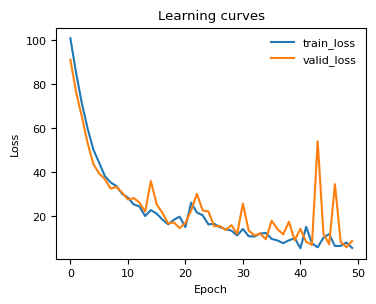

In [9]:
if not SKIP_TUTORIAL:
    from mlcolvar.utils.plot import plot_metrics

    fig, ax = plt.subplots(
        figsize=(4, 3)
    )

    plot_metrics(
        metrics.metrics,
        keys=["train_loss", "valid_loss"],
        yscale="linear",
        ax=ax,
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.show()


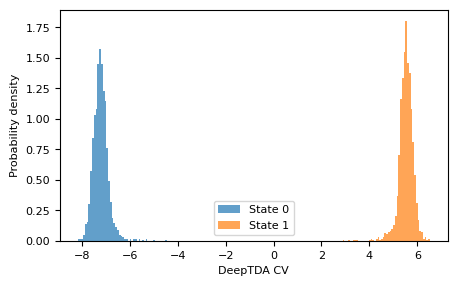

In [10]:
if not SKIP_TUTORIAL:
    labels = (
        cached_dataset["labels"]
        .reshape(-1)
        .cpu()
    )

    plt.figure(
        figsize=(5, 3)
    )

    for state in torch.unique(labels):
        mask = labels == state

        plt.hist(
            cached_cv[mask].numpy(),
            bins=50,
            density=True,
            alpha=0.7,
            label=f"State {int(state)}",
        )

    plt.xlabel("DeepTDA CV")
    plt.ylabel("Probability density")
    plt.legend()
    plt.show()


## 10. Export through Metatomic

Deployment uses the complete raw-input model, not the cache:

```text
Metatomic System
      ↓
frozen MACE representation
      ↓
pool_representation(...)
      ↓
trained TaskHead
      ↓
DeepTDA CV
```

The pooled system-level representation is already part of `representation`.
The cached features are only an optimization for training.

Backend-specific preparation for TorchScript export is handled by the
representation adapter. For example, `MACERepresentation` provides its own
TorchScript preparation logic, so users do not need to manually compile the
MACE model in this tutorial.


In [11]:
if not SKIP_TUTORIAL:
    from mlcolvar.representation.metatomic import (
        export_metatomic_model,
    )

    # ------------------------------------------------------------
    # Prepare the complete raw-input model for deployment
    # ------------------------------------------------------------

    raw_model = (
        raw_model
        .cpu()
        .eval()
    )

    # ------------------------------------------------------------
    # Metadata from the representation
    # ------------------------------------------------------------

    atomic_types = [
        int(value)
        for value
        in representation.atomic_numbers
        .detach()
        .cpu()
        .tolist()
    ]

    interaction_range = float(
        representation.cutoff
        .detach()
        .cpu()
        .item()
    )

    # ------------------------------------------------------------
    # Infer model precision
    # ------------------------------------------------------------

    first_parameter = next(
        raw_model.nn.parameters(),
        None,
    )

    if (
        first_parameter is not None
        and first_parameter.dtype == torch.float32
    ):
        dtype = "float32"
    else:
        dtype = "float64"

    # ------------------------------------------------------------
    # Export
    # ------------------------------------------------------------

    export_path = Path(
        "deep_tda_mace_pooled_metatomic.pt"
    )

    export_metatomic_model(
        model=raw_model,
        path=export_path,
        out_features=raw_model.n_cvs,
        atomic_types=atomic_types,
        interaction_range=interaction_range,
        length_unit="angstrom",
        dtype=dtype,

        # Export on CPU for maximum portability.
        # Add "cuda" only after validating the exported
        # model on CUDA.
        supported_devices=["cpu"],

        name=(
            "mlcolvar DeepTDA with "
            "MACE representation"
        ),
        description=(
            "DeepTDA collective variable using a frozen "
            "MACE atomistic representation and a trained "
            "task-specific readout."
        ),
    )

    print(
        "Saved model:",
        export_path.resolve(),
    )
    print(
        "Atomic types:",
        atomic_types,
    )
    print(
        "Interaction range:",
        interaction_range,
    )
    print(
        "Export dtype:",
        dtype,
    )
    print(
        "Supported devices:",
        ["cpu"],
    )


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Saved model: /home/kzhu-iit.local/data/mlcolvar-featurizer-clean/docs/notebooks/tutorials/deep_tda_mace_pooled_metatomic.pt
Atomic types: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Interaction range: 6.0
Export dtype: float32
Supported devices: ['cpu']


### PLUMED example

```plumed
h: GROUP ATOMS=...
c: GROUP ATOMS=...
n: GROUP ATOMS=...
o: GROUP ATOMS=...

cv: METATOMIC ...
    MODEL=./deep_tda_mace_pooled_metatomic.pt
    DEVICE=cpu
    SPECIES1=h
    SPECIES2=c
    SPECIES3=n
    SPECIES4=o
    SPECIES_TO_TYPES=1,6,7,8
...

opes: OPES_METAD ...
    ARG=cv.node-0
    PACE=500
    TEMP=300
    BARRIER=40
...

PRINT ARG=cv.node-0,opes.* FILE=COLVAR STRIDE=500
```

A custom `GraphRepresentation` can use the same downstream training and export
workflow as long as it exposes the required representation metadata and its
model can be exported through the selected deployment path.
